# Titanic 19 - Age 제거 / AgeBand only Experiment

## 가설

연속형 Age 대신 프로젝트에서 이미 사용한 구간형 AgeBand만 사용하면 나이의 비선형 생존 패턴을 더 안정적으로 표현할 수 있다.

변경: **Age 제거 / AgeBand only**. 그 외 전처리, CatBoost 파라미터, random_state=42, 25% stratified holdout, 5-fold stratified CV는 Titanic 18과 동일합니다.

> 주의: 현재 실제 Titanic 18에는 AgeBand가 없었습니다. 따라서 과거 프로젝트에서 사용한 AgeBand 경계를 재사용해 Age를 AgeBand로 대체합니다. 임의의 새 경계는 만들지 않았습니다.


# 1. 데이터 수집 및 확인


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

from common.evaluations import get_auc_score
from common.feature_experiments import fit_cat, baseline_parameters
from common.preprocessing import TitanicPreprocessor
from common.utils import train_test_split_by_target

ROOT = Path.cwd()
train = pd.read_csv(ROOT / "csv" / "train.csv")
test = pd.read_csv(ROOT / "csv" / "test.csv")
submission = pd.read_csv(ROOT / "csv" / "submission.csv")
print("train:", train.shape, "test:", test.shape, "submission:", submission.shape)
display(train.head())
display(test.head())


train: (916, 12) test: (393, 11) submission: (393, 2)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
1,917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
2,918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
3,919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
4,920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# 2. 메타 정보 확인


In [2]:
print("train columns:", train.columns.tolist())
print("test columns:", test.columns.tolist())
print("train missing ratio:\n", train.isna().mean().sort_values(ascending=False).to_string())
print("test missing ratio:\n", test.isna().mean().sort_values(ascending=False).to_string())
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print("train only:", train_only, "test only:", test_only)


train columns: ['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
test columns: ['passengerid', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
train missing ratio:
 cabin          0.783843
age            0.196507
embarked       0.001092
passengerid    0.000000
name           0.000000
pclass         0.000000
survived       0.000000
gender         0.000000
parch          0.000000
sibsp          0.000000
fare           0.000000
ticket         0.000000
test missing ratio:
 cabin          0.753181
age            0.211196
fare           0.002545
embarked       0.002545
name           0.000000
passengerid    0.000000
pclass         0.000000
parch          0.000000
sibsp          0.000000
gender         0.000000
ticket         0.000000
train only: {'survived'} test only: set()


# 3. Target 정의

train에만 있는 컬럼과 제출 템플릿을 교차 확인하고 ID는 Feature에서 제외합니다.


In [3]:
assert len(train_only) == 1 and not test_only
target_col = next(iter(train_only))
id_col = submission.columns[0]
assert submission.columns.tolist() == [id_col, target_col]
assert train[id_col].is_unique and test[id_col].is_unique
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
print("target:", target_col, "ID:", id_col, "X/y:", X.shape, y.shape)


target: survived ID: passengerid X/y: (916, 10) (916,)


# 4. Target 데이터 분석 및 분리

EDA와 전처리 전에 seed 42, stratify, validation 25%로 분리합니다.


In [4]:
assert set(y.unique()) == {0, 1}
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]
assert len(train_part) == 687 and len(valid_part) == 229
assert set(train_part[id_col]).isdisjoint(valid_part[id_col])
print("train/validation:", X_tr_raw.shape, X_valid_raw.shape)
print(y_tr.value_counts(normalize=True).sort_index().to_string())


train/validation: (687, 10) (229, 10)
survived
0    0.621543
1    0.378457


# 5. 실험 Feature 확인

이번 실험은 `Age 제거 / AgeBand only` 하나만 검증합니다.


In [5]:
class ExperimentPreprocessor(TitanicPreprocessor):
    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""

    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):
        self.use_logfare = use_logfare
        self.use_ageband = use_ageband
        self.remove_isalone = remove_isalone
        self.ticket_feature = ticket_feature

    def fit_missing(self, X):
        super().fit_missing(X)
        if self.ticket_feature is not None:
            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.
            self.ticket_counts_ = X["ticket"].value_counts()
        return self

    def feature_frame(self, raw, clean):
        data = self.make_features(clean)
        if self.use_logfare:
            data["LogFare"] = np.log1p(data["fare"])
        if self.use_ageband:
            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)
            data["AgeBand"] = pd.cut(
                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,
                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
            ).astype(str)
            data = data.drop(columns="age")
        if self.remove_isalone:
            data = data.drop(columns="IsAlone")
        if self.ticket_feature is not None:
            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)
            if self.ticket_feature == "NonFamilyGroupSize":
                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]
            elif self.ticket_feature == "TicketFarePerPerson":
                data["TicketFarePerPerson"] = data["fare"] / ticket_size
            elif self.ticket_feature == "NonFamilyGroupRatio":
                non_family_size = ticket_size - data["FamilySize"]
                data["NonFamilyGroupRatio"] = non_family_size / ticket_size
            else:
                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")
        return self.select_features(data)

    def fit_transform(self, X):
        self.fit_missing(X)
        data = self.feature_frame(X, self.transform_missing(X))
        self.fit_encoding(data)
        return self.transform_encoding(data)

    def transform(self, X):
        data = self.feature_frame(X, self.transform_missing(X))
        return self.transform_encoding(data)

experiment_prep = ExperimentPreprocessor(
    use_logfare=True,
    use_ageband=True,
    remove_isalone=False,
    ticket_feature=None,
)
experiment_prep.fit_missing(X_tr_raw)
X_tr_clean = experiment_prep.transform_missing(X_tr_raw)
X_valid_clean = experiment_prep.transform_missing(X_valid_raw)
assert not X_tr_clean.isna().any().any()
assert not X_valid_clean.isna().any().any()
print("제외 결측 컬럼:", experiment_prep.drop_missing_)
print("age 그룹 중앙값:\n", experiment_prep.age_groups_.to_string())


제외 결측 컬럼: ['cabin']
age 그룹 중앙값:
 gender  pclass
female  1         35.0
        2         27.0
        3         22.0
male    1         42.0
        2         30.0
        3         24.0


# 6. 데이터 전처리

학습 부분에서만 결측치 통계와 encoder를 fit하고 validation에는 transform만 적용합니다.


## 6-1. 결측치 처리


In [6]:
print("train clean missing:", int(X_tr_clean.isna().sum().sum()))
print("validation clean missing:", int(X_valid_clean.isna().sum().sum()))


train clean missing: 0
validation clean missing: 0


## 6-2. Feature 생성


In [7]:
X_tr_features = experiment_prep.feature_frame(X_tr_raw, X_tr_clean)
X_valid_features = experiment_prep.feature_frame(X_valid_raw, X_valid_clean)
print("모델 입력 전 Feature:", X_tr_features.columns.tolist())
display(X_tr_features.head())


모델 입력 전 Feature: ['pclass', 'gender', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone', 'LogFare', 'AgeBand']


,pclass,gender,sibsp,parch,fare,embarked,FamilySize,IsAlone,LogFare,AgeBand
595,3,male,0,1,9.3500,S,2,0,2.336987,Child
148,3,male,0,0,8.0500,S,1,1,2.202765,YoungAdult
347,3,female,1,1,15.2458,C,3,0,2.787834,Child
731,3,female,0,2,16.7000,S,3,0,2.873565,YoungAdult
457,2,male,0,0,13.0000,S,1,1,2.639057,Adult


## 6-3. 실험 조건 및 분포 검증


In [8]:
assert "age" not in X_tr_features.columns
assert "AgeBand" in X_tr_features.columns
print("AgeBand distribution:\n", X_tr_features["AgeBand"].value_counts().sort_index().to_string())
print("Target relation:\n", pd.DataFrame({"AgeBand": X_tr_features["AgeBand"], target_col: y_tr})
      .groupby("AgeBand")[target_col].agg(["size", "mean"]).to_string())


AgeBand distribution:
 AgeBand
Adult         173
Child          62
Senior         23
Teen           67
YoungAdult    362
Target relation:
             size      mean
AgeBand                   
Adult        173  0.375723
Child         62  0.516129
Senior        23  0.347826
Teen          67  0.388060
YoungAdult   362  0.356354


## 6-4. 데이터 인코딩

범주형은 학습 부분에서 One-Hot Encoding하고 미관측 범주는 무시합니다.


In [9]:
experiment_prep.fit_encoding(X_tr_features)
X_tr_model = experiment_prep.transform_encoding(X_tr_features)
X_valid_model = experiment_prep.transform_encoding(X_valid_features)
assert X_tr_model.columns.equals(X_valid_model.columns)
print("범주형:", experiment_prep.cat_cols_)
print("인코딩 후:", X_tr_model.shape, X_valid_model.shape)
print("Encoded Feature 목록:", X_tr_model.columns.tolist())


범주형: ['gender', 'embarked', 'AgeBand']
인코딩 후: (687, 17) (229, 17)
Encoded Feature 목록: ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'LogFare', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult']


## 6-5. 데이터 스케일링

Titanic 18과 같은 트리 기반 CatBoost이므로 스케일링은 생략합니다.


In [10]:
assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()
assert X_tr_model.index.equals(y_tr.index)
print("NaN/Inf 없음, index 일치")


NaN/Inf 없음, index 일치


# 7. 모델 학습

Titanic 18과 같은 CatBoost 기본 파라미터와 random_state=42를 유지합니다.


In [11]:
model = fit_cat(X_tr_model, y_tr)
assert model.get_params() == baseline_parameters()
print("model:", model.__class__.__name__)
print("parameters:", model.get_params())


model: CatBoostClassifier
parameters: {'verbose': 0, 'allow_writing_files': False, 'random_state': 42, 'cat_features': []}


# 8. Evaluation - AUC


In [12]:
positive_index = list(model.classes_).index(1)
train_probability = model.predict_proba(X_tr_model)[:, positive_index]
valid_probability = model.predict_proba(X_valid_model)[:, positive_index]
train_auc = get_auc_score(y_tr, train_probability)
validation_auc = get_auc_score(y_valid, valid_probability)
gap = train_auc - validation_auc
print(f"Train AUC: {train_auc:.6f}")
print(f"Validation AUC: {validation_auc:.6f}")
print(f"Train / Validation Gap: {gap:.6f}")


Train AUC: 0.964272
Validation AUC: 0.895552
Train / Validation Gap: 0.068720


In [13]:
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
for fold, (train_index, valid_index) in enumerate(splitter.split(X, y), 1):
    fold_prep = ExperimentPreprocessor(
    use_logfare=True,
    use_ageband=True,
    remove_isalone=False,
    ticket_feature=None,
)
    X_fold_train = fold_prep.fit_transform(X.iloc[train_index])
    X_fold_valid = fold_prep.transform(X.iloc[valid_index])
    fold_model = fit_cat(X_fold_train, y.iloc[train_index])
    fold_positive = list(fold_model.classes_).index(1)
    fold_auc = get_auc_score(y.iloc[valid_index], fold_model.predict_proba(X_fold_valid)[:, fold_positive])
    fold_scores.append(fold_auc)
    print(f"Fold {fold}: {fold_auc:.6f}")
cv_mean = float(np.mean(fold_scores))
cv_std = float(np.std(fold_scores, ddof=1))
print(f"Cross Validation Mean: {cv_mean:.6f}")
print(f"Cross Validation Std: {cv_std:.6f}")


Fold 1: 0.903258
Fold 2: 0.916730
Fold 3: 0.888762
Fold 4: 0.900394
Fold 5: 0.912789
Cross Validation Mean: 0.904387
Cross Validation Std: 0.011004


# 9. 전체 train 데이터로 최종 학습

새 전처리 객체를 전체 train에 fit하고 같은 CatBoost로 재학습합니다.


In [14]:
full_prep = ExperimentPreprocessor(
    use_logfare=True,
    use_ageband=True,
    remove_isalone=False,
    ticket_feature=None,
)
X_full_model = full_prep.fit_transform(X)
X_test_model = full_prep.transform(X_test_raw)
assert X_full_model.columns.equals(X_test_model.columns)
assert np.isfinite(X_full_model.to_numpy()).all()
assert np.isfinite(X_test_model.to_numpy()).all()
full_model = fit_cat(X_full_model, y)
print("전체 train/test 변환:", X_full_model.shape, X_test_model.shape)
print("최종 Feature 목록:", X_full_model.columns.tolist())


전체 train/test 변환: (916, 17) (393, 17)
최종 Feature 목록: ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'LogFare', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult']


# 10. test 예측

Titanic 18과 동일하게 양성 클래스 확률을 제출합니다.


In [15]:
assert len(submission) == len(test)
assert submission[id_col].equals(test[id_col])
full_positive_index = list(full_model.classes_).index(1)
predictions = full_model.predict_proba(X_test_model)[:, full_positive_index]
assert np.isfinite(predictions).all()
assert ((predictions >= 0) & (predictions <= 1)).all()
print("prediction range:", float(predictions.min()), float(predictions.max()))


prediction range: 0.00967739230421036 0.9986734590266629


# 11. titanic_19_result.csv 생성

원본 submission 템플릿의 ID와 행 순서를 유지합니다.


In [16]:
result = submission.copy(deep=True)
by_id = pd.Series(predictions, index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
result_path = ROOT / "submission" / "titanic_19_result.csv"
result.to_csv(result_path, index=False)
saved = pd.read_csv(result_path)
checks = {
    "test 행 수 일치": len(saved) == len(test),
    "원본 shape 유지": saved.shape == submission.shape,
    "컬럼명/순서 유지": saved.columns.equals(submission.columns),
    "ID 값/순서 유지": saved[id_col].equals(submission[id_col]),
    "NaN 없음": saved[target_col].notna().all(),
    "확률 0~1 범위": saved[target_col].between(0, 1).all(),
}
assert all(checks.values()), checks
print("저장:", result_path)
print("검증:", checks)
display(saved.head())


저장: c:\dev\study\machine_learning\submission\titanic_19_result.csv
검증: {'test 행 수 일치': True, '원본 shape 유지': True, '컬럼명/순서 유지': True, 'ID 값/순서 유지': True, 'NaN 없음': np.True_, '확률 0~1 범위': np.True_}


,passengerid,survived
0,916,0.716961
1,917,0.894917
2,918,0.884018
3,919,0.084695
4,920,0.966903


# 12. Feature Importance

SHAP 때문에 학습 구조를 바꾸지 않고, CatBoost의 동일 모델 기반 Feature Importance를 출력합니다.


gender_female         26.126246
gender_male           25.961172
pclass                10.242656
fare                   8.675879
LogFare                8.253200
FamilySize             3.836403
sibsp                  3.276114
AgeBand_Child          2.960746
AgeBand_Adult          2.047067
parch                  1.873757
embarked_S             1.860727
AgeBand_YoungAdult     1.498398
embarked_C             1.048244
embarked_Q             0.804944
IsAlone                0.595731
AgeBand_Teen           0.557610
AgeBand_Senior         0.381106


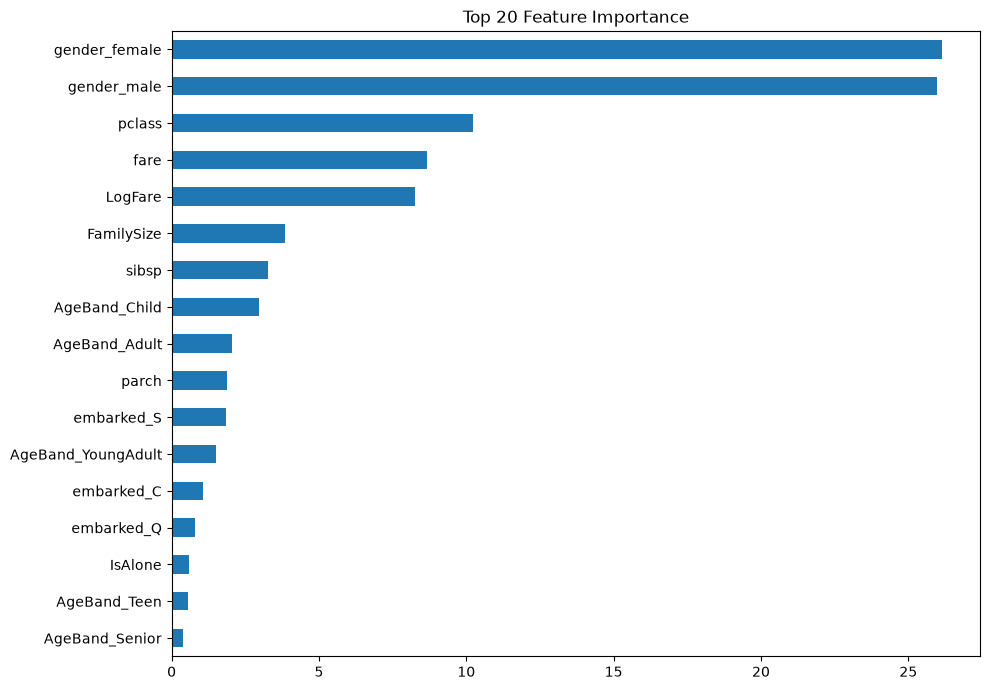

In [17]:
importance = pd.Series(full_model.feature_importances_, index=X_full_model.columns, name="importance")
importance = importance.sort_values(ascending=False)
print(importance.to_string())
importance.sort_values().tail(20).plot.barh(figsize=(10, 7), title="Top 20 Feature Importance")
plt.tight_layout()
plt.show()


# 13. 실험 결과 요약


In [18]:
print("Experiment: Titanic 19")
print("Change: Age 제거 / AgeBand only")
print(f"Train AUC: {train_auc:.6f}")
print(f"Validation AUC: {validation_auc:.6f}")
print(f"Gap: {gap:.6f}")
print(f"CV Mean: {cv_mean:.6f}")
print(f"CV Std: {cv_std:.6f}")
print("Feature 목록:", X_full_model.columns.tolist())
print("Submission:", result_path)


Experiment: Titanic 19
Change: Age 제거 / AgeBand only
Train AUC: 0.964272
Validation AUC: 0.895552
Gap: 0.068720
CV Mean: 0.904387
CV Std: 0.011004
Feature 목록: ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'LogFare', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult']
Submission: c:\dev\study\machine_learning\submission\titanic_19_result.csv


# 14. Confusion Matrix

마지막 분석 셀은 validation의 0/1 최종 예측으로 Confusion Matrix를 출력하고 시각화합니다.


TN: 0.888
FP: 0.112
FN: 0.209
TP: 0.791


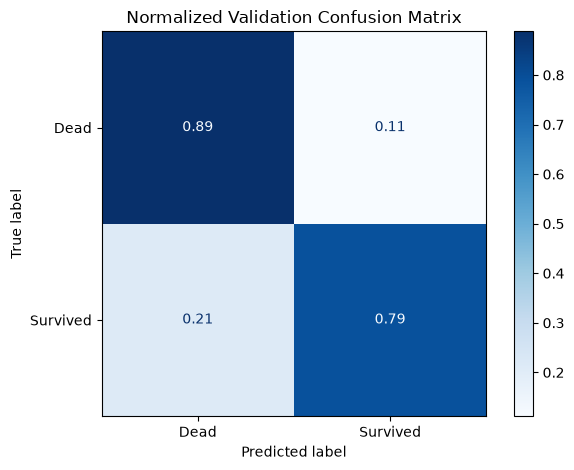

In [19]:
valid_prediction = model.predict(X_valid_model).astype(int)

# 행(True Label)을 기준으로 정규화
cm = confusion_matrix(
    y_valid,
    valid_prediction,
    labels=[0, 1],
    normalize="true"
)

tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn:.3f}")
print(f"FP: {fp:.3f}")
print(f"FN: {fn:.3f}")
print(f"TP: {tp:.3f}")

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dead", "Survived"]
)

display_cm.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.title("Normalized Validation Confusion Matrix")
plt.tight_layout()
plt.show()